# Module 1 — Fluorouracil: Patient Population

Who are the patients in these fluorouracil reports? This notebook characterizes the population using two angles:

- **Indication profile** — what conditions were patients being treated for when 5-FU was reported? (`indi` table)
- **Demographics** — age distribution, sex breakdown, and top reporting countries (`demo` table)

Understanding the patient population contextualizes the reaction and outcome findings in the adjacent notebooks.

**Prerequisite:** Run `01_5fu_explore.ipynb` first to ensure the `fluorouracil_analysis` table exists in the database.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

In [3]:
indications = pd.read_sql_query("""
SELECT indi_pt, COUNT(*) AS indication
FROM indi
JOIN (SELECT DISTINCT primaryid FROM fluorouracil_analysis) f
    ON indi.primaryid = f.primaryid
GROUP BY indi_pt
ORDER BY indication DESC
""", conn)

indications.head(10)

,indi_pt,indication
0,Product used for unknown indication,6271
1,Colorectal cancer metastatic,3165
2,Colon cancer,2032
3,Oesophageal adenocarcinoma,1668
4,Colorectal cancer,1609
5,Adenocarcinoma of colon,1425
6,Gastric cancer,983
7,Adenocarcinoma gastric,971
8,Rectal cancer,874
9,Oesophageal carcinoma,852


In [4]:
indications.shape

(641, 2)

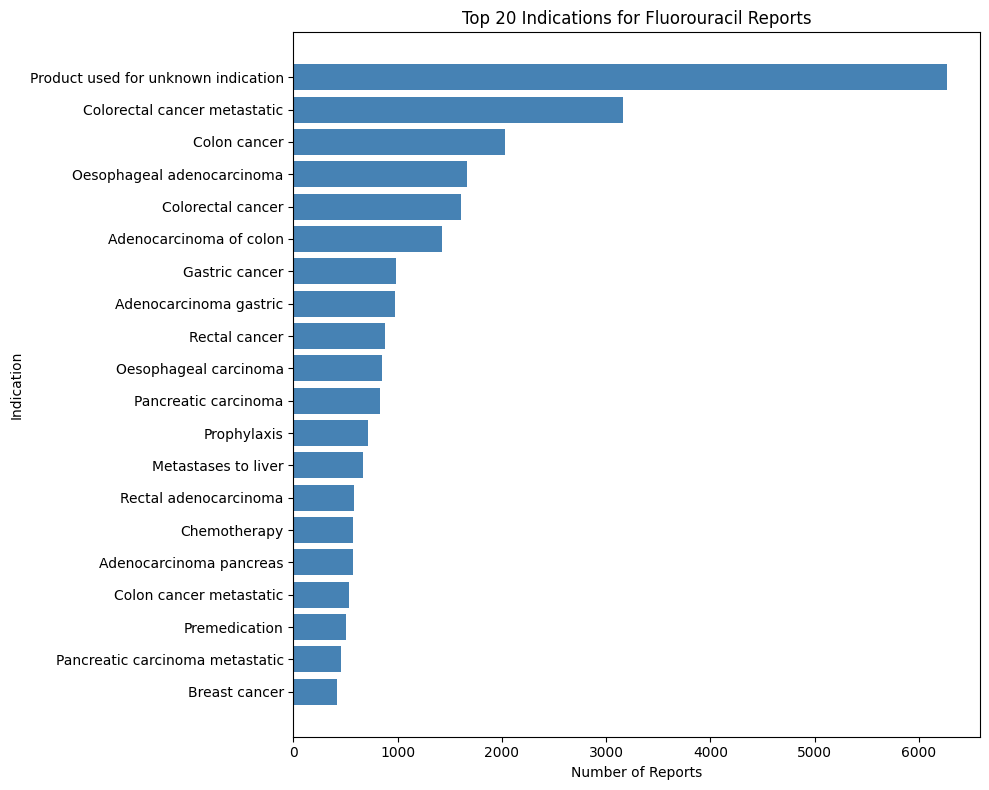

In [5]:
plt.figure(figsize=(10, 8))
plt.barh(indications['indi_pt'][:20], indications['indication'][:20], color='steelblue')
plt.xlabel('Number of Reports')
plt.ylabel('Indication')
plt.title('Top 20 Indications for Fluorouracil Reports')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [6]:
all_indications = pd.read_sql_query("""
SELECT indi_pt, COUNT(*) AS cnt
FROM indi
JOIN (SELECT DISTINCT primaryid FROM fluorouracil_analysis) f
    ON indi.primaryid = f.primaryid
GROUP BY indi_pt
ORDER BY cnt DESC
LIMIT 100
""", conn)

all_indications

,indi_pt,cnt
0,Product used for unknown indication,6271
1,Colorectal cancer metastatic,3165
2,Colon cancer,2032
3,Oesophageal adenocarcinoma,1668
4,Colorectal cancer,1609
...,...,...
95,Diabetes mellitus,43
96,Bile duct cancer,43
97,Oesophageal neoplasm,40
98,Signet-ring cell carcinoma,39


In [7]:
## Filter by indication of interest (e.g., colorectal cancer) to focus on a more homogeneous patient population for modeling and EDA. 
# This will help understand the specific drug combinations and outcomes relevant to that indication.


# "Product used for unknown indication" is the most common value in FAERS — reporters frequently
# omit indication, especially in manufacturer-submitted reports and off-label use cases.
# These are excluded by the cancer-term filter below.



filter_indication_terms = ['colorectal', 'colon', 'rectal', 'appendix', 'peritoneum',
                           'gastric', 'oesophageal', 'pancreatic', 'cholangiocarcinoma']

like_clauses = " OR ".join([f"indi_pt LIKE '%{term}%'" for term in filter_indication_terms])

filtered_indications = pd.read_sql_query(f"""
SELECT indi_pt, COUNT(*) AS indication
FROM indi
JOIN (SELECT DISTINCT primaryid FROM fluorouracil_analysis) f
    ON indi.primaryid = f.primaryid
WHERE {like_clauses}
GROUP BY indi_pt
ORDER BY indication DESC
""", conn)

filtered_indications.head(50)

,indi_pt,indication
0,Colorectal cancer metastatic,3165
1,Colon cancer,2032
2,Oesophageal adenocarcinoma,1668
3,Colorectal cancer,1609
4,Adenocarcinoma of colon,1425
5,Gastric cancer,983
6,Adenocarcinoma gastric,971
7,Rectal cancer,874
8,Oesophageal carcinoma,852
9,Pancreatic carcinoma,831


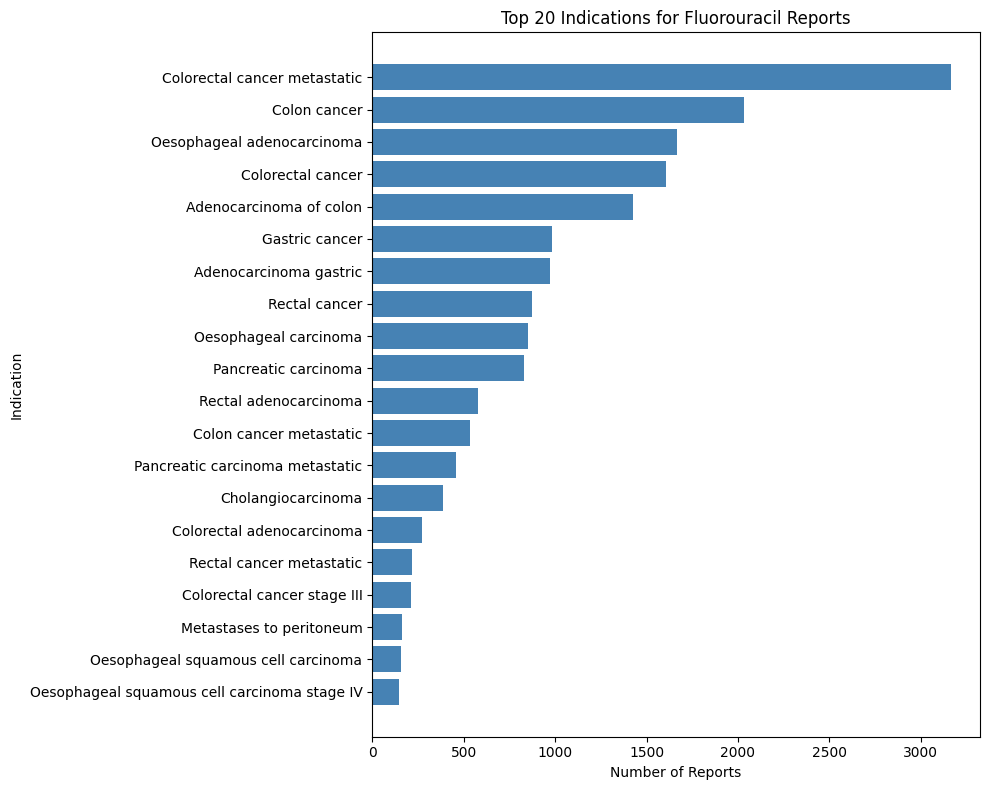

In [8]:
plt.figure(figsize=(10, 8))
plt.barh(filtered_indications['indi_pt'][:20], filtered_indications['indication'][:20], color='steelblue')
plt.xlabel('Number of Reports')
plt.ylabel('Indication')
plt.title('Top 20 Indications for Fluorouracil Reports')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

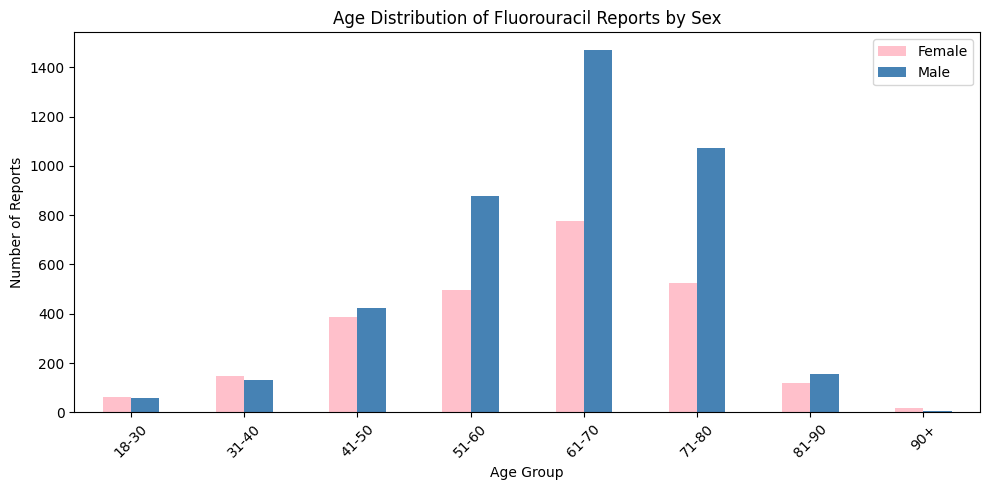

In [9]:
### Now we will look for demographic information in the reports to understand the patient population better.

##Start by join age and sex values with distinct primary IDs from the fluorouracil_analysis table to focus on the relevant reports. 
# 
# This will help us understand the demographics of patients receiving 5-FU and identify any patterns or trends in age and sex distribution 
# that may be relevant for our modeling and EDA.

demographics = pd.read_sql_query("""
SELECT age, sex
FROM demo
JOIN (SELECT DISTINCT primaryid FROM fluorouracil_analysis) f
    ON demo.primaryid = f.primaryid
WHERE age IS NOT NULL
  AND age BETWEEN 18 AND 110
""", conn)

demographics['age_group'] = pd.cut(
    demographics['age'],
    bins=[18, 30, 40, 50, 60, 70, 80, 90, 110],
    labels=['18-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '90+']
)

age_sex = (
    demographics.groupby(['age_group', 'sex'])
    .size()
    .unstack(fill_value=0)
)

age_sex[['F', 'M']].plot(
    kind='bar',
    figsize=(10, 5),
    color={'F': 'pink', 'M': 'steelblue'}
)

plt.xlabel('Age Group')
plt.ylabel('Number of Reports')
plt.title('Age Distribution of Fluorouracil Reports by Sex')
plt.xticks(rotation=45)
plt.legend(['Female', 'Male'])
plt.tight_layout()
plt.show()



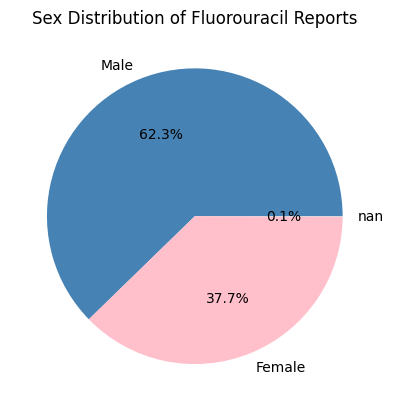

In [23]:
import pandas as pd
import matplotlib.pyplot as plt


sex_counts = demographics['sex'].value_counts()
sex_counts.index = sex_counts.index.map({'M': 'Male', 'F': 'Female', 'U': 'Unknown', 'NS': 'Not Specified'})

plt.pie(
    sex_counts,
    labels=sex_counts.index,
    autopct='%1.1f%%',
    colors=['steelblue', 'pink', 'lightgrey', 'lightgrey']
)
plt.title('Sex Distribution of Fluorouracil Reports')
plt.show()


### Observations

- **61–70 is the peak reporting age group** for both sexes, consistent with the known median diagnosis age for colorectal cancer (mid-60s).
- **Male predominance across all age groups** aligns with colorectal cancer's slightly higher incidence in men.
- **Female reports are relatively higher in the 61–70 and 71–80 range**, possibly reflecting breast cancer patients — 5-FU is used in breast cancer regimens, which skews female and older.
- **Sharp drop after 80** likely reflects both reduced chemotherapy use and underreporting in elderly patients.

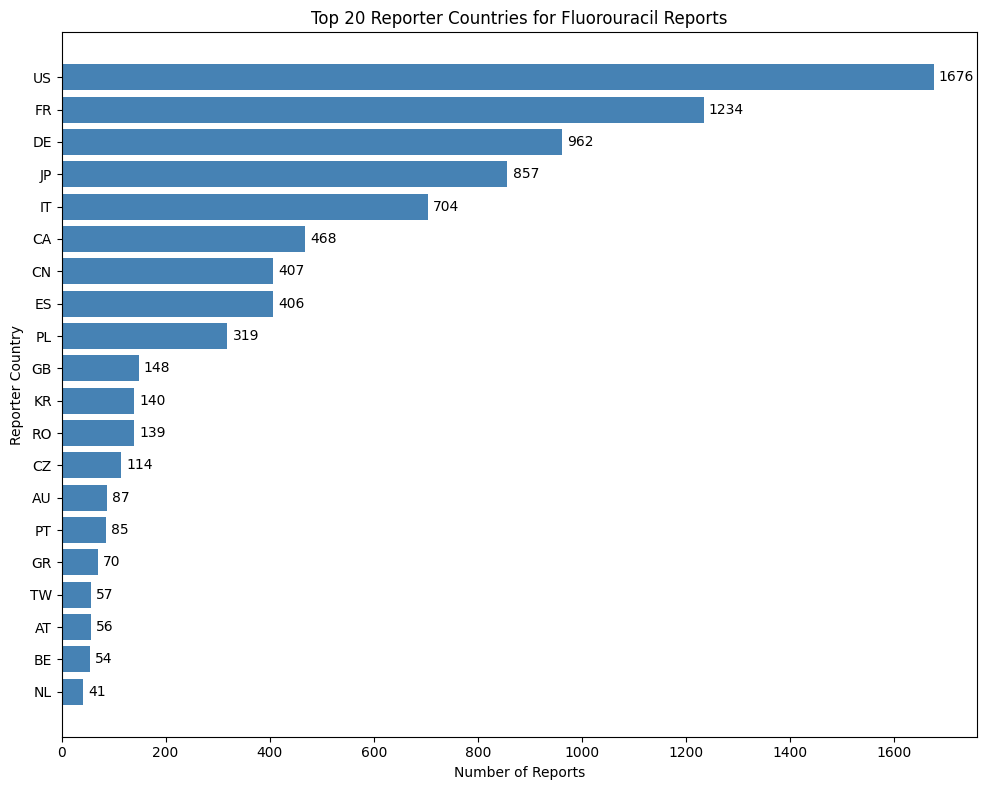

In [19]:
##

report_countries = pd.read_sql_query("""
SELECT reporter_country, COUNT(*) AS reports
FROM demo
                                     JOIN (SELECT DISTINCT primaryid FROM fluorouracil_analysis) f
                                     ON demo.primaryid = f.primaryid
WHERE reporter_country IS NOT NULL
GROUP BY reporter_country
ORDER BY reports DESC
""", conn)

report_countries.head(20)


plt.figure(figsize=(10, 8))
plt.barh(report_countries['reporter_country'][:20], report_countries['reports'][:20], color='steelblue')
plt.xlabel('Number of Reports')
plt.ylabel('Reporter Country')
plt.title('Top 20 Reporter Countries for Fluorouracil Reports')
plt.gca().invert_yaxis()
for i, v in enumerate(report_countries['reports'][:20]):
    plt.text(v + 10, i, str(v), va='center')
plt.tight_layout()
plt.show()